In [245]:
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold 
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor

Question 1: Data Loading, Exploration and Preprocessing 
1(a) Load the Dataset 
Load the California Housing dataset as a Pandas DataFrame. 

In [246]:
#The first five observations;  
df = pd.read_csv("california_housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [247]:
#The dimensions of the dataset;  
print('Number of dimensions:',df.ndim)

Number of dimensions: 2


In [248]:
#The names of all variables.
print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


1(b) Data Inspection 

In [249]:
#The data type of each variable;
print(df.dtypes)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [250]:
#The number of missing values in each variable;  
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [251]:
#The number of duplicated observations;  
print('Number of duplicates:', df.duplicated().sum())

Number of duplicates: 0


In [252]:
#Descriptive statistics for all variables; 
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [253]:
#detect outliers
Q1 = df["MedInc"].quantile(0.25) 
Q3 = df["MedInc"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["MedInc"] < lower) | 
(df["MedInc"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.58500
131,11.6017,18.0,8.335052,1.082474,533.0,2.747423,37.84,-122.19,3.92600
134,8.2049,28.0,6.978947,0.968421,463.0,2.436842,37.83,-122.19,3.35200
135,8.4010,26.0,7.530806,1.056872,542.0,2.568720,37.83,-122.20,3.51200
...,...,...,...,...,...,...,...,...,...
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


In [254]:
Q1 = df["HouseAge"].quantile(0.25) 
Q3 = df["HouseAge"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["HouseAge"] < lower) | 
(df["HouseAge"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


In [255]:
Q1 = df["AveRooms"].quantile(0.25) 
Q3 = df["AveRooms"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["AveRooms"] < lower) | 
(df["AveRooms"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
73,0.4999,46.0,1.714286,0.571429,18.0,2.571429,37.81,-122.29,0.67500
155,8.8793,52.0,8.972868,1.131783,861.0,3.337209,37.81,-122.23,4.10300
511,13.4990,42.0,8.928358,1.000000,1018.0,3.038806,37.82,-122.22,5.00001
512,12.2138,52.0,9.210227,1.039773,1001.0,2.843750,37.82,-122.23,5.00001
514,12.3804,52.0,9.122715,1.033943,1192.0,3.112272,37.82,-122.23,5.00001
...,...,...,...,...,...,...,...,...,...
20408,7.7889,26.0,8.730038,1.045627,842.0,3.201521,34.19,-118.88,3.09900
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


In [256]:
Q1 = df["AveBedrms"].quantile(0.25) 
Q3 = df["AveBedrms"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["AveBedrms"] < lower) | 
(df["AveBedrms"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
41,1.2852,51.0,3.759036,1.248996,517.0,2.076305,37.83,-122.26,1.500
57,0.8172,52.0,6.102459,1.372951,728.0,2.983607,37.82,-122.28,0.853
59,2.5625,2.0,2.771930,0.754386,94.0,1.649123,37.82,-122.29,0.600
61,6.1183,49.0,5.869565,1.260870,86.0,3.739130,37.82,-122.29,0.750
62,0.9011,50.0,6.229508,1.557377,377.0,3.090164,37.81,-122.29,0.861
...,...,...,...,...,...,...,...,...,...
20423,5.4346,17.0,6.261168,1.505155,578.0,1.986254,34.08,-119.00,4.286
20608,1.7167,24.0,5.400000,1.273171,768.0,3.746341,39.10,-121.59,0.488
20620,4.5625,40.0,4.125000,0.854167,151.0,3.145833,39.05,-121.48,1.000
20621,2.3661,37.0,7.923567,1.573248,484.0,3.082803,39.01,-121.47,0.775


In [257]:
Q1 = df["Population"].quantile(0.25) 
Q3 = df["Population"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["Population"] < lower) | 
(df["Population"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
95,2.0096,36.0,2.294016,1.066294,3469.0,1.493328,37.80,-122.26,1.300
185,2.1917,43.0,4.844029,1.091795,4367.0,3.547522,37.79,-122.23,1.128
283,5.9849,22.0,6.528724,1.041179,4985.0,2.534316,37.79,-122.16,3.710
460,1.4012,52.0,3.105714,1.060000,3337.0,9.534286,37.87,-122.26,1.750
485,1.6307,35.0,2.962687,1.001148,3276.0,1.880597,37.86,-122.26,2.536
...,...,...,...,...,...,...,...,...,...
20543,1.7311,33.0,3.882852,1.029994,3717.0,2.103565,38.55,-121.74,1.826
20544,2.0650,23.0,4.803493,1.013646,6330.0,3.455240,38.55,-121.76,2.194
20563,3.1250,9.0,5.148007,1.119593,6837.0,2.899491,38.67,-121.75,1.325
20604,2.3496,17.0,4.551392,0.962527,3265.0,3.495717,39.12,-121.54,0.650


In [258]:
Q1 = df["AveOccup"].quantile(0.25) 
Q3 = df["AveOccup"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["AveOccup"] < lower) | 
(df["AveOccup"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
91,0.8668,52.0,2.443182,0.988636,904.0,10.272727,37.80,-122.28,1.37500
92,0.7500,52.0,2.823529,0.911765,191.0,5.617647,37.80,-122.28,1.62500
200,3.0257,52.0,4.046948,1.009390,994.0,4.666667,37.78,-122.23,0.80800
270,3.8750,33.0,3.021277,0.659574,575.0,12.234043,37.78,-122.18,2.25000
...,...,...,...,...,...,...,...,...,...
20353,5.0066,12.0,3.800000,1.466667,69.0,4.600000,34.13,-119.05,2.75000
20393,5.7560,16.0,6.117493,1.026110,2007.0,5.240209,34.22,-118.88,3.02700
20513,2.6250,34.0,5.597403,1.103896,391.0,5.077922,38.67,-121.63,2.25000
20527,1.4653,7.0,3.525794,1.017857,4479.0,8.886905,38.54,-121.79,3.10000


In [259]:
Q1 = df["Latitude"].quantile(0.25) 
Q3 = df["Latitude"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["Latitude"] < lower) | 
(df["Latitude"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


In [260]:
Q1 = df["Longitude"].quantile(0.25) 
Q3 = df["Longitude"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["Longitude"] < lower) | 
(df["Longitude"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


In [261]:
Q1 = df["MedHouseVal"].quantile(0.25) 
Q3 = df["MedHouseVal"].quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = df[(df["MedHouseVal"] < lower) | 
(df["MedHouseVal"] > upper)] 
outliers

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
140,6.3624,30.0,5.615385,0.730769,126.0,2.423077,37.81,-122.18,4.83300
459,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001
489,3.0417,48.0,4.690632,1.126362,1656.0,3.607843,37.86,-122.25,4.89600
493,7.8521,52.0,7.794393,1.051402,517.0,2.415888,37.86,-122.24,5.00001
...,...,...,...,...,...,...,...,...,...
20422,5.1457,35.0,6.958333,1.217593,576.0,2.666667,34.14,-118.90,5.00001
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


In [262]:
print(df.max())

MedInc            15.000100
HouseAge          52.000000
AveRooms         141.909091
AveBedrms         34.066667
Population     35682.000000
AveOccup        1243.333333
Latitude          41.950000
Longitude       -114.310000
MedHouseVal        5.000010
dtype: float64


In [263]:
print(df.min())

MedInc           0.499900
HouseAge         1.000000
AveRooms         0.846154
AveBedrms        0.333333
Population       3.000000
AveOccup         0.692308
Latitude        32.540000
Longitude     -124.350000
MedHouseVal      0.149990
dtype: float64


1(c) Exploratory Data Analysis

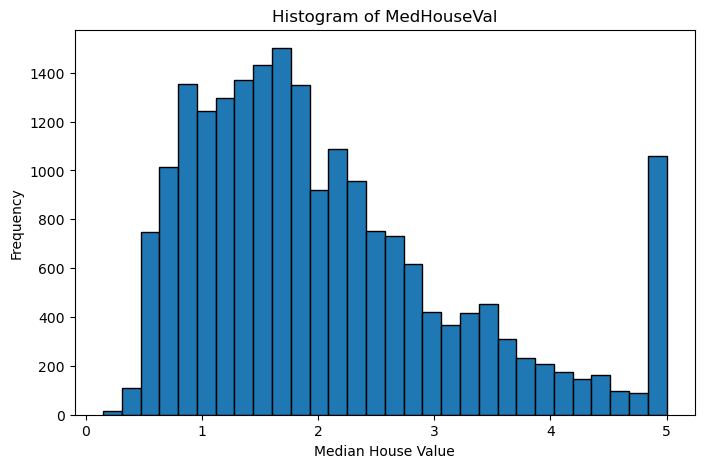

In [264]:
#A histogram of MedHouseVal; 
plt.figure(figsize=(8,5))
plt.hist(df["MedHouseVal"],
         bins=30,edgecolor="black")
plt.title("Histogram of MedHouseVal")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

storytelling
The histogram tells the story of housing prices in California. Most homes are concentrated in the lower to middle price range, with the highest frequency of median house values between approximately 1.0 and 2.5. As house values increase beyond this range, the number of homes steadily decreases, indicating that expensive homes are less common. However, there is a noticeable spike at the maximum value of 5.0, suggesting that many house prices were capped at this value in the dataset. Overall, the distribution is positively (right) skewed, meaning that while most neighborhoods have relatively affordable median house values, a smaller number of neighborhoods have much higher values. This indicates that high-value homes are comparatively rare but still make up an important portion of the housing market.

In [265]:
#A correlation matrix containing all predictors and the target; 
corr_matrix=df.corr()
print(corr_matrix)

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

<function matplotlib.pyplot.show(close=None, block=None)>

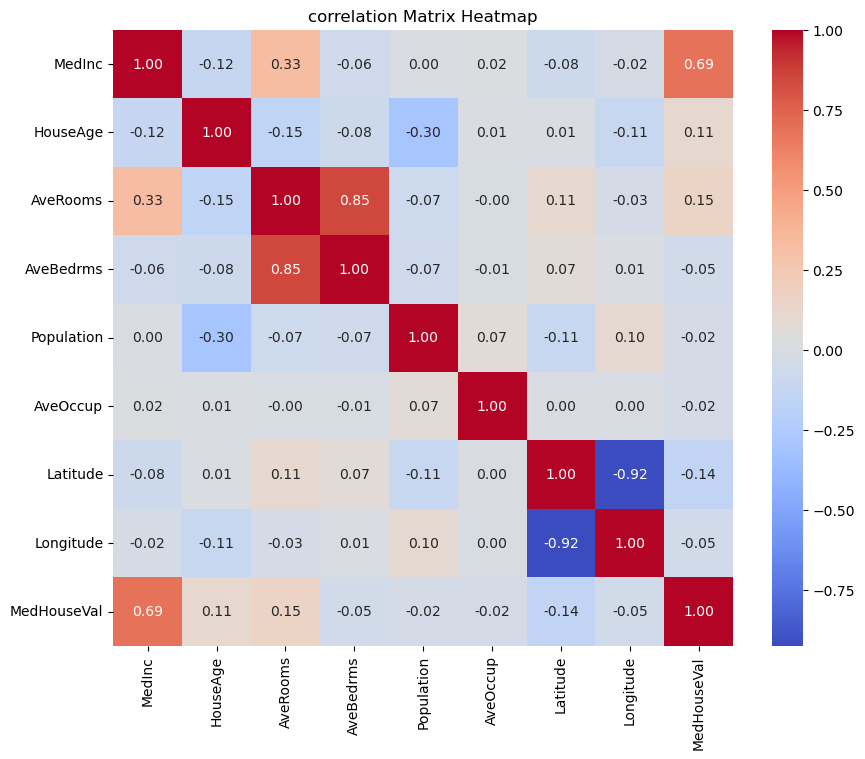

In [266]:
#A heatmap of the correlation matrix;
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation Matrix Heatmap")
plt.show

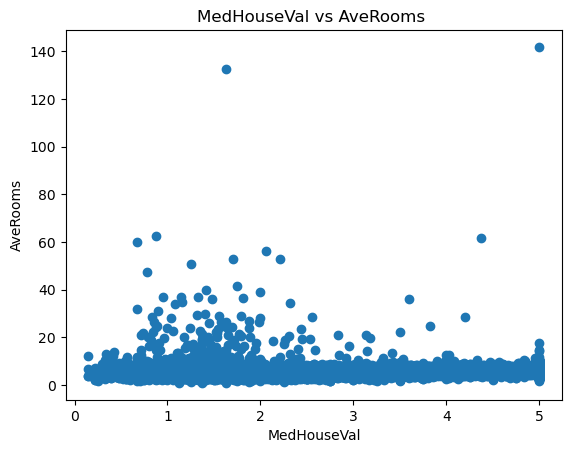

In [267]:
#At least two scatter plots showing the relationship between selected predictors and 
#MedHouseVal.  

plt.scatter(df["MedHouseVal"], df["AveRooms"]) 
plt.title("MedHouseVal vs AveRooms " ) 
plt.xlabel("MedHouseVal") 
plt.ylabel("AveRooms") 
plt.show() 

Storytelling:
The scatter plot shows the relationship between median house value (MedHouseVal) and average number of rooms (AveRooms). Most neighborhoods have an average of 5 to 10 rooms, forming a dense cluster across nearly all house values.
While there is a slight tendency for neighborhoods with more rooms to have higher house values, the relationship is not strongly linear. House prices vary considerably even among areas with similar average room counts, indicating that the number of rooms alone is not a reliable predictor of house value.
The graph also contains several extreme outliers, where the average number of rooms exceeds 50 and even 100. These values are unusual and may represent data anomalies or very uncommon housing districts. Such outliers should be investigated because they may affect statistical models.
Key Insight:
Average rooms may have a weak positive relationship with house value, but it is not sufficient on its own to explain price variations. Additional variables, such as median income, house age, or geographical location, are likely to have a stronger impact.

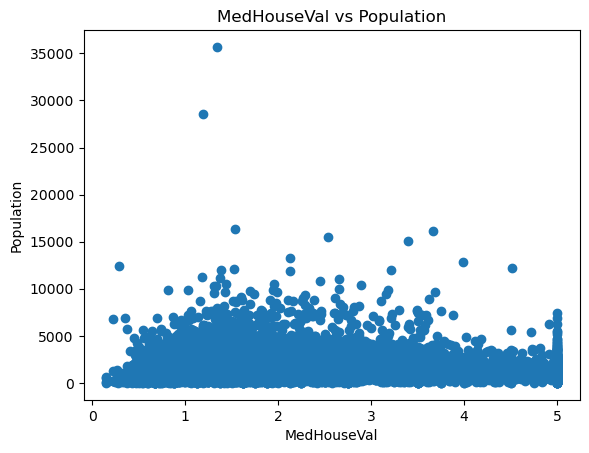

In [268]:
plt.scatter(df["MedHouseVal"],df["Population"]) 
plt.title("MedHouseVal vs Population" ) 
plt.xlabel("MedHouseVal") 
plt.ylabel("Population") 
plt.show() 

Storytelling:
The scatter plot illustrates the relationship between median house value (MedHouseVal) and population. Most observations are concentrated at lower population values, regardless of the median house value, suggesting that neighborhoods with smaller populations are more common in the dataset.
The points are widely scattered with no clear upward or downward trend, indicating that population alone does not strongly influence house prices. Although a few neighborhoods with very large populations exist, they are spread across different house values rather than being associated with consistently higher or lower prices.
There are also several noticeable outliers, where some districts have exceptionally large populations compared to the rest of the data. These extreme values may represent densely populated urban areas and could influence statistical analyses if left untreated.
Key Insight:
Population does not appear to have a strong linear relationship with median house value. This suggests that other factors, such as income level, location, or housing characteristics, are likely more important in determining house prices.

1(d) Feature Encoding and scaling 

In [269]:
#Perform a feature encoding on categorical features and scaling on numerical features. 
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()
df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']] = scaler.fit_transform(df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']]) 
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,4.526
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,3.585
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,3.521
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,3.413
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,3.422
...,...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826,0.781
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722,0.771
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713,0.923
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626,0.847


NO 2(a) - Train-Test Split: Split the dataset into: • 80% training data;
• 20% testing data.
Use: random_state=42

In [270]:
# Predictor (must be 2D)
X = df[["MedInc", "HouseAge", "AveRooms","AveBedrms", "Population","AveOccup", "Latitude", "Longitude"]]

# Target / Response
y = df["MedHouseVal"]

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = True, random_state=42)

2(b) Model Fitting: Fit a Multiple Linear Regression model using all eight predictor variables. Use: from sklearn.linear_model import LinearRegression Train the model only on the training dataset.

In [271]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [272]:
#Make predictions
y_pred = model.predict(X_test)

data = {"actual": y_test, "predicted": y_pred}

pred_df = pd.DataFrame(data)
pred_df

,actual,predicted
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
...,...,...
15362,2.63300,1.991746
16623,2.66800,2.249839
18086,5.00001,4.468770
2144,0.72300,1.187511


2(c) Model Evaluation 
Generate predictions for both the training and testing sets.

In [273]:
y_pred_train = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)
Mae=mean_absolute_error(y_train, y_pred_train)
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"R²   : {r2_train:.4f}")
print(f"Mae  :{Mae:.4f}")

MSE  : 0.5179
RMSE : 0.7197
R²   : 0.6126
Mae  :0.5286


In [274]:
#### Performance of the model on the test set
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
Mae=mean_absolute_error(y_test, y_pred)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"Mae  :{Mae:.4f}")

MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758
Mae  :0.5332


In [275]:
dta = {"Train": {"MSE":0.5179, "RMSE":0.7197, "R_squared": 0.6126, "Mae"  :0.5286 }, 
       "Test": {"MSE":0.5559, "RMSE":0.7456, "R_squared":0.5758, "Mae" :0.5332}}
final_df = pd.DataFrame(dta)
final_df

,Train,Test
MSE,0.5179,0.5559
RMSE,0.7197,0.7456
R_squared,0.6126,0.5758
Mae,0.5286,0.5332


 2(d) Interpretation 
Based on the training and testing results, state whether the model appears to: 
• underfit;  
• generalising well;  
• overfit.  
Justify your conclusion.

Answer
The Model generalizes well because similar training and testing error suggests the model is stable.

Question 3: Five-Fold Cross-Validation 
3(a) Cross-Validation Strategy 

In [276]:
#Create a five-fold cross-validation procedure
cv = KFold( 
n_splits=5, 
shuffle=True, 
random_state=42 
)
cv

KFold(n_splits=5, random_state=42, shuffle=True)

Shuffling= True randomly shuffles the observations before splitting, making each fold more representative of the whole dataset.

Random_state=42 ensures the same random split obtained everytime the code is run, making the experiment reproducible.

3(b) Cross-Validation Implementation 

In [277]:
#Evaluate the Linear Regression model using cross_validate.
Model=LinearRegression()
cv = KFold( 
n_splits=5, 
shuffle=True, 
random_state=42 
)
scores= cross_validate(estimator = Model,
    X = X_train,
    y = y_train,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    return_train_score = True
)

In [278]:
#Convert the negative MSE values returned by scikit-learn into positive values before 
#interpreting them. 
neg_test_mse = scores['test_score']
neg_train_mse = scores['train_score']

#Converting to positive values(by multiplying by -1)
test_mse = -neg_test_mse
train_mse = -neg_train_mse

#Printing the positive values and their averages
print("--- Validation (Test) Folds MSE ----")
print(f"MSE per fold: {test_mse}")
print(f"Average Validation MSE: {test_mse.mean():.4f}")

print("\n--- Training Folds MSE ----")
print(f"MSE per fold: {train_mse}")
print(f"Average Training MSE: {train_mse.mean():.4f}")


--- Validation (Test) Folds MSE ----
MSE per fold: [0.52006533 0.50229277 0.52054451 0.50789718 0.54552622]
Average Validation MSE: 0.5193

--- Training Folds MSE ----
MSE per fold: [0.51755214 0.52189804 0.51738817 0.52094688 0.51119526]
Average Training MSE: 0.5178


3(d) Comparison

Compare the average five-fold cross-validation result with the result obtained from the single 
train-test split. 

Answers
The 5_fold cross validation MSE(0.5193) is almost the same as the training MSE(0.5179). This shows that the Model is performing very well.

Question 4, 5 and 6: Ridge Regression Using GridSearchCV,  Lasso Regression Using GridSearchCV ,  Elastic Net Regression Using GridSearchCV .

In [279]:
#4(a) Build a Ridge Pipeline 
#Create a pipeline containing: 
#1. StandardScaler;  
#2. Ridge. 

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())])
ridge_pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


4(b) Hyperparameter Tuning 

4(c) Model Evaluation 

In [280]:
Lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())])
Lasso_pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True


In [281]:
ElasticNet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet())])
ElasticNet_pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False


In [282]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

In [283]:
Lasso_pipeline = Lasso() 
Ridge_pipeline = Ridge() 
ElasticNet_pipeline = ElasticNet()

In [284]:
Lasso_grid={"alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10] } 

grid= GridSearchCV( 
estimator=Lasso_pipeline, 
param_grid=Lasso_grid, 
cv=5, 
scoring='neg_mean_squared_error' 
) 
grid.fit(X_train, y_train) 
print("Best alpha:", grid.best_params_) 
print("Best CV Score:", grid.best_score_) 
best_Lasso = grid.best_estimator_

Best alpha: {'alpha': 0.001}
Best CV Score: -0.5192487792639193


In [285]:
Ridge_grid={"alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000 ] } 

grid= GridSearchCV( 
estimator=Ridge_pipeline, 
param_grid=Ridge_grid, 
cv=5, 
scoring='neg_mean_squared_error' 
) 
grid.fit(X_train, y_train) 
print("Best alpha:", grid.best_params_) 
print("Best CV Score:", grid.best_score_) 
best_Ridge = grid.best_estimator_

Best alpha: {'alpha': 1}
Best CV Score: -0.5192651569791898


In [286]:
Elastic_grid={"alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10  ],
"l1_ratio": [ 0.1, 0.3, 0.5, 0.7, 0.9 ]  } 

grid= GridSearchCV( 
estimator=ElasticNet_pipeline, 
param_grid=Elastic_grid, 
cv=5, 
scoring='neg_mean_squared_error' 
) 
grid.fit(X_train, y_train) 
print("Best alpha:", grid.best_params_) 
print("Best CV Score:", grid.best_score_) 
best_ElasticNet = grid.best_estimator_

Best alpha: {'alpha': 0.001, 'l1_ratio': 0.9}
Best CV Score: -0.5192501433935758


In [287]:
Lasso_pred = best_Lasso.predict(X_test)
Ridge_pred=best_Ridge.predict(X_test)
Elastic_pred = best_ElasticNet.predict(X_test)

In [288]:
models = { 
"Lasso_pipeline": (best_Lasso, Lasso_pred), 
"Ridge_pipeline": (best_Ridge, Ridge_pred), 
"ElasticNet_pipeline": (best_ElasticNet, Elastic_pred) 
} 
for name, (model, pred) in models.items(): 
    mse = mean_squared_error(y_test, pred) 
    rmse = np.sqrt(mse) 
    r2 = r2_score(y_test, pred) 
    print(f"\n{name}") 
    print(f"Best Parameters : {model.get_params()}") 
    print(f"MSE             : {mse:.4f}") 
    print(f"RMSE            : {rmse:.4f}") 
    print(f"R²              : {r2:.4f}") 
    print(f"MAE             :{Mae:.4f}")


Lasso_pipeline
Best Parameters : {'alpha': 0.001, 'copy_X': True, 'fit_intercept': True, 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}
MSE             : 0.5544
RMSE            : 0.7446
R²              : 0.5769
MAE             :0.5332

Ridge_pipeline
Best Parameters : {'alpha': 1, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
MSE             : 0.5559
RMSE            : 0.7456
R²              : 0.5758
MAE             :0.5332

ElasticNet_pipeline
Best Parameters : {'alpha': 0.001, 'copy_X': True, 'fit_intercept': True, 'l1_ratio': 0.9, 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}
MSE             : 0.5545
RMSE            : 0.7446
R²              : 0.5769
MAE             :0.5332


Intepretation 4d
Explain how the Ridge penalty affects the regression coefficients. State whether Ridge 
normally reduces coefficients exactly to zero. 

Answer
How the Ridge penalty affects coefficients:

Ordinary Linear Regression finds the coefficients that minimize only the sum of squared residuals (the prediction error). Ridge Regression adds a second term to that objective — a penalty proportional to the sum of squared coefficients (the L2 norm), scaled by the hyperparameter α: Loss = Sum of Squared Residuals + α × Σ(coefficient²) This penalty discourages the model from assigning large weights to any predictor. The larger α is, the more heavily large coefficients are punished, so the model is forced to shrink them toward zero to keep the overall loss low. This is why Ridge is called a shrinkage method — every coefficient gets pulled closer to zero, roughly in proportion to its size, rather than the model being allowed to fit the training data as tightly as possible. The practical effect: Ridge trades a small increase in bias for a meaningful reduction in variance. By preventing any single feature (or a group of correlated features) from dominating the model with an inflated coefficient, Ridge reduces the model's sensitivity to noise and multicollinearity in the training data, which typically improves generalization to unseen data

Does Ridge reduce coefficients exactly to zero?

No. Ridge shrinks coefficients toward zero but never sets them exactly to zero (except in the unusual edge case where a feature has zero relationship with the target that would put it there anyway). This is because the L2 penalty (squared coefficients) has a smooth, continuously differentiable derivative — as a coefficient gets closer to zero, the "pull" from the penalty gets progressively weaker, so it never fully pushes it to exactly zero. This is the key structural difference from Lasso Regression, which uses an L1 penalty (sum of absolute values of coefficients instead of squares). The L1 penalty's geometry does allow coefficients to be driven exactly to zero, which is why Lasso is often used for feature selection — it can effectively eliminate irrelevant predictors from the model entirely. Ridge, in contrast, keeps all features in the model, just with reduced influence.


5(d) Feature Selection 
Count the number of coefficients reduced exactly to zero. Identify the variables removed by 
Lasso and explain why Lasso can be used as a feature-selection method.

In [290]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Get the best model from GridSearchCV
Lasso_model = grid.best_estimator_

# Get the coefficients
coefficients = Lasso_model.coef_

# Create a DataFrame of features and coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

# Count coefficients that are exactly zero
num_zero = np.sum(coefficients == 0)

# Identify the removed features
removed_features = coef_df[coef_df["Coefficient"] == 0]

# Display results
print("Number of coefficients reduced to zero:", num_zero)

print("\nVariables removed by Lasso:")
print(removed_features)

# (Optional) Display all coefficients
coef_df



Number of coefficients reduced to zero: 0

Variables removed by Lasso:
Empty DataFrame
Columns: [Feature, Coefficient]
Index: []


,Feature,Coefficient
0,MedInc,0.847230
1,HouseAge,0.123238
2,AveRooms,-0.291653
3,AveBedrms,0.356801
4,Population,-0.001134
5,AveOccup,-0.035948
6,Latitude,-0.885611
7,Longitude,-0.857271


Why Lasso can be used as a feature-selection method

Lasso regression is an effective feature-selection method because it applies L1 regularization, which adds a penalty to the absolute values of the regression coefficients. As the regularization strength (α) increases, the coefficients of less important features are shrunk toward zero. Features whose coefficients become exactly zero are effectively removed from the model, leaving only the most important predictors. This produces a simpler and more interpretable model while helping to reduce overfitting.

In this case, the selected value of α was not large enough to shrink any coefficient to exactly zero, so no features were eliminated. This indicates that, under the chosen level of regularization, all predictor variables contributed some information to the model.

6(d) Interpretation 
Explain how Elastic Net combines the characteristics of Ridge and Lasso. Count the number 
of coefficients reduced exactly to zero. 

In [292]:
# Get the Elastic Net model from the pipeline
ElasticNet_model = grid.best_estimator_

# Get the coefficients
coefficients = ElasticNet_model.coef_

# Create a DataFrame
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

# Count coefficients that are exactly zero
num_zero = np.sum(coefficients == 0)

# Identify removed variables
removed_features = coef_df[coef_df["Coefficient"] == 0]

# Display results
print("Number of coefficients reduced to zero:", num_zero)
print("\nVariables removed by Elastic Net:")
print(removed_features)

# Display all coefficients
coef_df

Number of coefficients reduced to zero: 0

Variables removed by Elastic Net:
Empty DataFrame
Columns: [Feature, Coefficient]
Index: []


,Feature,Coefficient
0,MedInc,0.847230
1,HouseAge,0.123238
2,AveRooms,-0.291653
3,AveBedrms,0.356801
4,Population,-0.001134
5,AveOccup,-0.035948
6,Latitude,-0.885611
7,Longitude,-0.857271


The Elastic Net model did not remove any predictor variables because none of the coefficients were reduced exactly to zero. This indicates that, for the optimal values of α and l1_ratio, every predictor contributed to the model. Although some coefficients may have been shrunk toward zero, none were eliminated completely.

Question 7: Model Performance Comparison

In [ ]:
#Create a table with the following structure
Model_Performance_Table = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'],
    'Optimal Alpha': ['N/A', 1, 0.001, 0.001],
    'Optimal L1 Ratio': ['N/A', 'N/A', 'N/A', 0.9],
    'Test MSE': [0.5599, 0.5559, 0.5544, 0.5545],
    'Test RMSE': [0.7456, 0.7456, 0.7446, 0.7446],
    'Test MAE': [0.5332, 0.5332, 0.5332, 0.5332],
    'Test R²': [0.5758, 0.5758, 0.5769, 0.5769]
})
Model_Performance_Table

1. Which model has the lowest test MSE?  Lasso Model
2. Which model has the lowest test RMSE? Lasso and ElasticNet Model  
3. Which model has the lowest test MAE? None all equal 
4. Which model has the highest test 𝑅2? Lasso and ElasticNet Model   
5. Did regularisation improve predictive performance? yes, but slightly 
6. Are the differences between the models practically important? yes  
7. Which model would you recommend for prediction? Lasso Model
8. Give a reason for your recommendation. It is recommended because it gives the lowest Mean Squared Error(MSE).

Question 8: Coefficient Shrinkage Comparison

In [ ]:
linear_regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_regression_pipeline.fit(X_train, y_train)


In [ ]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_grid = {
    'model__alpha': [0.0001,0.001,0.01,0.1,1,10,100,1000]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    ridge_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_search.fit(X_train, y_train)


In [ ]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

lasso_grid = {
    'model__alpha':[0.0001,0.001,0.01,0.1,1,10]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    lasso_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

lasso_search.fit(X_train,y_train)


In [ ]:
elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])

elastic_grid = {
    'model__alpha':[0.0001,0.001,0.01,0.1,1],
    'model__l1_ratio':[0.1,0.3,0.5,0.7,0.9]
}

elastic_search = GridSearchCV(
    elastic_pipeline,
    elastic_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

elastic_search.fit(X_train,y_train)


In [ ]:
# Predictor names
features = X.columns

coef_table = pd.DataFrame({
    'Feature':features,
    'Linear Regression':
        linear_regression_pipeline.named_steps['model'].coef_,
    'Ridge':
        ridge_search.best_estimator_.named_steps['model'].coef_,
    'Lasso':
        lasso_search.best_estimator_.named_steps['model'].coef_,
    'Elastic Net':
        elastic_search.best_estimator_.named_steps['model'].coef_
})

print(coef_table)


1. Which model produces the largest coefficient magnitudes?  Linear Regression and Ridge
2. Does Ridge shrink most coefficients towards zero?  No
3. Does Ridge set any coefficients exactly to zero?  No
4. Which coefficients are set to zero by Lasso? None 
5. Which coefficients are set to zero by Elastic Net? None  
6. Which model produces the sparsest solution? None 
7. Which model is most appropriate for automatic feature selection? Lasso   
8. Which model is generally more suitable when predictors are strongly correlated? Ridge

Question 9: Visualisation and Final Interpretation 

Produce a grouped bar chart comparing the coefficients of: 
• Linear Regression;  
• Ridge;  
• Lasso;  
• Elastic Net. 

In [ ]:
coef_data = coef_table.set_index('Feature')

x = np.arange(len(coef_data.index))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x-1.5*width,
        coef_data['Linear Regression'],
        width,
        label='Linear')

plt.bar(x-0.5*width,
        coef_data['Ridge'],
        width,
        label='Ridge')

plt.bar(x+0.5*width,
        coef_data['Lasso'],
        width,
        label='Lasso')

plt.bar(x+1.5*width,
        coef_data['Elastic Net'],
        width,
        label='Elastic Net')

plt.xticks(x, coef_data.index, rotation=45)

plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison")
plt.legend()

plt.tight_layout()
plt.show()


1. Coefficient Shrinkage
Linear Regression produced the largest coefficient magnitudes. Ridge Regression showed almost no shrinkage because its coefficients are nearly identical to those of Linear Regression. Lasso and Elastic Net slightly reduced the coefficient magnitudes by shrinking them toward zero, but the reduction was small.
2. Feature Selection
Neither Lasso nor Elastic Net set any coefficient exactly to zero. Therefore, no features were removed, and all predictors remained in the models. Although Lasso is generally used for automatic feature selection, the chosen regularization parameter was not strong enough to eliminate any feature.
3. Predictive Performance
The four models are expected to have very similar predictive performance because their coefficients are nearly identical. Since Ridge, Lasso, and Elastic Net apply regularization, they generally provide better generalization than ordinary Linear Regression, especially when multicollinearity is present. However, in this dataset, the differences in predictive performance are likely to be minimal.
4. Final Recommended Model
Ridge Regression is the recommended model. It provides regularization that helps reduce overfitting and handles correlated predictors effectively while maintaining the predictive performance of Linear Regression. Although Lasso and Elastic Net also regularize the model, they did not perform feature selection in this case, making Ridge the most suitable choice.


Question 10: Perform a SGD using the dataset and compute the MAE, MSE and RMSE on 
the test data

In [ ]:
sgd_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(
        random_state=42,
        max_iter=1000,
        tol=1e-3
    ))
])

sgd_model.fit(X_train, y_train)

y_pred = sgd_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
